In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Load the data
df = pd.read_csv("../data/raw/results.csv")
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

print(f"Loaded {len(df):,} matches")
df.head()

Loaded 49,287 matches


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1872
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1873
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1874
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1875
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1876


In [2]:
# Drop any rows with missing scores (shouldn't be many, but safe to check)
before = len(df)
df = df.dropna(subset=["home_score", "away_score"])
after = len(df)

print(f"Removed {before - after} rows with missing scores")
print(f"Working with {after:,} matches")

Removed 72 rows with missing scores
Working with 49,215 matches


In [3]:
def get_result(row):
    if row["home_score"] > row["away_score"]:
        return "H"
    elif row["home_score"] < row["away_score"]:
        return "A"
    else:
        return "D"

df["result"] = df.apply(get_result, axis=1)

print(df["result"].value_counts())
print(df["result"].value_counts(normalize=True).round(3))

result
H    24106
A    13912
D    11197
Name: count, dtype: int64
result
H    0.490
A    0.283
D    0.228
Name: proportion, dtype: float64


In [4]:
home_rows = pd.DataFrame({
    "date": df["date"],
    "team": df["home_team"],
    "opponent": df["away_team"],
    "is_home": True,
    "is_neutral": df["neutral"],
    "goals_for": df["home_score"],
    "goals_against": df["away_score"],
    "tournament": df["tournament"],
})

away_rows = pd.DataFrame({
    "date": df["date"],
    "team": df["away_team"],
    "opponent": df["home_team"],
    "is_home": False,
    "is_neutral": df["neutral"],
    "goals_for": df["away_score"],
    "goals_against": df["home_score"],
    "tournament": df["tournament"],
})

team_matches = pd.concat([home_rows, away_rows], ignore_index=True)
team_matches["goal_diff"] = team_matches["goals_for"] - team_matches["goals_against"]

def team_result(row):
    if row["goals_for"] > row["goals_against"]:
        return "W"
    elif row["goals_for"] < row["goals_against"]:
        return "L"
    else:
        return "D"

team_matches["result"] = team_matches.apply(team_result, axis=1)
team_matches = team_matches.sort_values(["team", "date"]).reset_index(drop=True)

print(f"Long format: {len(team_matches):,} team-match rows")
team_matches.head(10)

Long format: 98,430 team-match rows


,date,team,opponent,is_home,is_neutral,goals_for,goals_against,tournament,goal_diff,result
0,2012-09-25,Abkhazia,Artsakh,True,False,1.0,1.0,Friendly,0.0,D
1,2012-10-21,Abkhazia,Artsakh,False,False,0.0,3.0,Friendly,-3.0,L
2,2014-06-01,Abkhazia,Occitania,True,True,1.0,1.0,CONIFA World Football Cup,0.0,D
3,2014-06-02,Abkhazia,Sápmi,False,False,2.0,1.0,CONIFA World Football Cup,1.0,W
4,2014-06-04,Abkhazia,South Ossetia,True,True,0.0,0.0,CONIFA World Football Cup,0.0,D
5,2014-06-05,Abkhazia,Padania,False,True,3.0,3.0,CONIFA World Football Cup,0.0,D
6,2014-06-07,Abkhazia,Occitania,True,True,0.0,1.0,CONIFA World Football Cup,-1.0,L
7,2015-05-05,Abkhazia,Luhansk PR,True,False,1.0,0.0,Friendly,1.0,W
8,2015-05-14,Abkhazia,Donetsk PR,True,False,1.0,0.0,Friendly,1.0,W
9,2016-05-21,Abkhazia,Donetsk PR,True,False,0.0,0.0,Friendly,0.0,D


In [5]:
home_rows = pd.DataFrame({
    "date": df["date"],
    "team": df["home_team"],
    "opponent": df["away_team"],
    "is_home": True,
    "is_neutral": df["neutral"],
    "goals_for": df["home_score"],
    "goals_against": df["away_score"],
    "tournament": df["tournament"],
})

away_rows = pd.DataFrame({
    "date": df["date"],
    "team": df["away_team"],
    "opponent": df["home_team"],
    "is_home": False,
    "is_neutral": df["neutral"],
    "goals_for": df["away_score"],
    "goals_against": df["home_score"],
    "tournament": df["tournament"],
})

team_matches = pd.concat([home_rows, away_rows], ignore_index=True)
team_matches["goal_diff"] = team_matches["goals_for"] - team_matches["goals_against"]

def team_result(row):
    if row["goals_for"] > row["goals_against"]:
        return "W"
    elif row["goals_for"] < row["goals_against"]:
        return "L"
    else:
        return "D"

team_matches["result"] = team_matches.apply(team_result, axis=1)
team_matches = team_matches.sort_values(["team", "date"]).reset_index(drop=True)

print(f"Long format: {len(team_matches):,} team-match rows")
team_matches.head(10)

Long format: 98,430 team-match rows


,date,team,opponent,is_home,is_neutral,goals_for,goals_against,tournament,goal_diff,result
0,2012-09-25,Abkhazia,Artsakh,True,False,1.0,1.0,Friendly,0.0,D
1,2012-10-21,Abkhazia,Artsakh,False,False,0.0,3.0,Friendly,-3.0,L
2,2014-06-01,Abkhazia,Occitania,True,True,1.0,1.0,CONIFA World Football Cup,0.0,D
3,2014-06-02,Abkhazia,Sápmi,False,False,2.0,1.0,CONIFA World Football Cup,1.0,W
4,2014-06-04,Abkhazia,South Ossetia,True,True,0.0,0.0,CONIFA World Football Cup,0.0,D
5,2014-06-05,Abkhazia,Padania,False,True,3.0,3.0,CONIFA World Football Cup,0.0,D
6,2014-06-07,Abkhazia,Occitania,True,True,0.0,1.0,CONIFA World Football Cup,-1.0,L
7,2015-05-05,Abkhazia,Luhansk PR,True,False,1.0,0.0,Friendly,1.0,W
8,2015-05-14,Abkhazia,Donetsk PR,True,False,1.0,0.0,Friendly,1.0,W
9,2016-05-21,Abkhazia,Donetsk PR,True,False,0.0,0.0,Friendly,0.0,D


In [6]:
points_map = {"W": 3, "D": 1, "L": 0}
team_matches["points"] = team_matches["result"].map(points_map)

team_matches["is_win"] = (team_matches["result"] == "W").astype(int)
team_matches["is_draw"] = (team_matches["result"] == "D").astype(int)
team_matches["is_loss"] = (team_matches["result"] == "L").astype(int)

team_matches[["date", "team", "opponent", "goals_for", "goals_against", "result", "points"]].head(10)

,date,team,opponent,goals_for,goals_against,result,points
0,2012-09-25,Abkhazia,Artsakh,1.0,1.0,D,1
1,2012-10-21,Abkhazia,Artsakh,0.0,3.0,L,0
2,2014-06-01,Abkhazia,Occitania,1.0,1.0,D,1
3,2014-06-02,Abkhazia,Sápmi,2.0,1.0,W,3
4,2014-06-04,Abkhazia,South Ossetia,0.0,0.0,D,1
5,2014-06-05,Abkhazia,Padania,3.0,3.0,D,1
6,2014-06-07,Abkhazia,Occitania,0.0,1.0,L,0
7,2015-05-05,Abkhazia,Luhansk PR,1.0,0.0,W,3
8,2015-05-14,Abkhazia,Donetsk PR,1.0,0.0,W,3
9,2016-05-21,Abkhazia,Donetsk PR,0.0,0.0,D,1


In [7]:
team_matches.to_csv("../data/processed/team_matches.csv", index=False)
print(f"Saved {len(team_matches):,} rows to data/processed/team_matches.csv")

Saved 98,430 rows to data/processed/team_matches.csv


In [8]:
# Make sure we're sorted by team, then date (essential for rolling)
team_matches = team_matches.sort_values(["team", "date"]).reset_index(drop=True)

# Window size — last 10 matches
N = 10

# Group by team so each team's rolling stats are calculated independently
grouped = team_matches.groupby("team")

# Rolling form features — note the .shift(1) to avoid leakage
team_matches["form_points"]       = grouped["points"].shift(1).rolling(N, min_periods=3).mean()
team_matches["form_goals_for"]    = grouped["goals_for"].shift(1).rolling(N, min_periods=3).mean()
team_matches["form_goals_against"] = grouped["goals_against"].shift(1).rolling(N, min_periods=3).mean()
team_matches["form_goal_diff"]    = grouped["goal_diff"].shift(1).rolling(N, min_periods=3).mean()
team_matches["form_win_rate"]     = grouped["is_win"].shift(1).rolling(N, min_periods=3).mean()

print("Rolling form features built!")
team_matches[["date", "team", "opponent", "goals_for", "goals_against", 
              "form_points", "form_goals_for", "form_goals_against", "form_win_rate"]].head(20)

Rolling form features built!


,date,team,opponent,goals_for,goals_against,form_points,form_goals_for,form_goals_against,form_win_rate
0,2012-09-25,Abkhazia,Artsakh,1.0,1.0,NaN,NaN,NaN,NaN
1,2012-10-21,Abkhazia,Artsakh,0.0,3.0,NaN,NaN,NaN,NaN
2,2014-06-01,Abkhazia,Occitania,1.0,1.0,NaN,NaN,NaN,NaN
3,2014-06-02,Abkhazia,Sápmi,2.0,1.0,0.666667,0.666667,1.666667,0.000000
4,2014-06-04,Abkhazia,South Ossetia,0.0,0.0,1.250000,1.000000,1.500000,0.250000
5,2014-06-05,Abkhazia,Padania,3.0,3.0,1.200000,0.800000,1.200000,0.200000
6,2014-06-07,Abkhazia,Occitania,0.0,1.0,1.166667,1.166667,1.500000,0.166667
7,2015-05-05,Abkhazia,Luhansk PR,1.0,0.0,1.000000,1.000000,1.428571,0.142857
8,2015-05-14,Abkhazia,Donetsk PR,1.0,0.0,1.250000,1.000000,1.250000,0.250000
9,2016-05-21,Abkhazia,Donetsk PR,0.0,0.0,1.444444,1.000000,1.111111,0.333333


In [9]:
# Pick a team with lots of history — let's try Brazil
brazil_recent = team_matches[team_matches["team"] == "Brazil"].tail(15)

brazil_recent[["date", "opponent", "goals_for", "goals_against", "result",
               "form_points", "form_goals_for", "form_win_rate"]]

,date,opponent,goals_for,goals_against,result,form_points,form_goals_for,form_win_rate
11085,2024-10-15,Peru,4.0,0.0,W,1.7,1.5,0.4
11086,2024-11-14,Venezuela,1.0,1.0,D,1.9,1.6,0.5
11087,2024-11-19,Uruguay,1.0,1.0,D,1.7,1.4,0.4
11088,2025-03-20,Colombia,2.0,1.0,W,1.7,1.4,0.4
11089,2025-03-25,Argentina,1.0,4.0,L,1.9,1.6,0.5
11090,2025-06-05,Ecuador,0.0,0.0,D,1.6,1.3,0.4
11091,2025-06-10,Paraguay,1.0,0.0,W,1.6,1.2,0.4
11092,2025-09-04,Chile,3.0,0.0,W,1.8,1.3,0.5
11093,2025-09-09,Bolivia,0.0,1.0,L,1.8,1.5,0.5
11094,2025-10-10,South Korea,5.0,0.0,W,1.8,1.5,0.5


In [10]:
# How many rows have all form features calculated (not NaN)?
has_form = team_matches["form_points"].notna()
print(f"Rows with form features: {has_form.sum():,} out of {len(team_matches):,}")
print(f"That's {has_form.mean()*100:.1f}% of the data")

# Look at a few with missing values (early in a team's history)
print("\nSample of rows missing form (early career matches):")
team_matches[~has_form].head(5)[["date", "team", "opponent", "form_points"]]

Rows with form features: 98,427 out of 98,430
That's 100.0% of the data

Sample of rows missing form (early career matches):


,date,team,opponent,form_points
0,2012-09-25,Abkhazia,Artsakh,NaN
1,2012-10-21,Abkhazia,Artsakh,NaN
2,2014-06-01,Abkhazia,Occitania,NaN


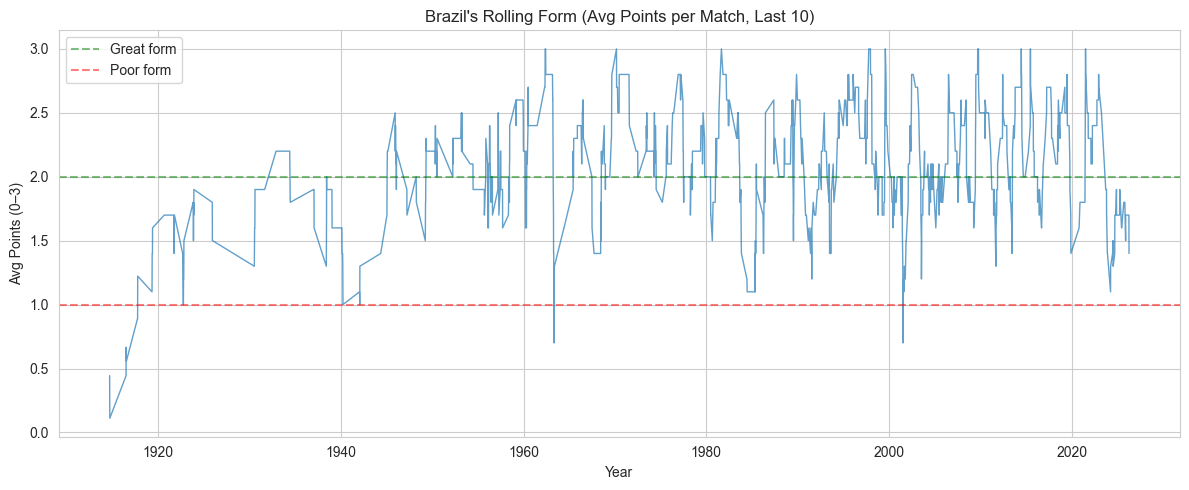

In [11]:
# Plot Brazil's form over time
brazil = team_matches[team_matches["team"] == "Brazil"].copy()

plt.figure(figsize=(12, 5))
plt.plot(brazil["date"], brazil["form_points"], linewidth=1, alpha=0.7)
plt.title("Brazil's Rolling Form (Avg Points per Match, Last 10)")
plt.xlabel("Year")
plt.ylabel("Avg Points (0–3)")
plt.axhline(y=2, color="green", linestyle="--", alpha=0.5, label="Great form")
plt.axhline(y=1, color="red", linestyle="--", alpha=0.5, label="Poor form")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
team_matches.to_csv("../data/processed/team_matches.csv", index=False)
print(f"Saved {len(team_matches):,} rows with form features")

Saved 98,430 rows with form features
